In [ ]:
pip install selenium pandas lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [ ]:
"""
=============================================================================
RBI Payment System Indicators — Production-Grade ETL Pipeline
=============================================================================
Project : The War on Cash — India's Digital Payment Ecosystem Analysis
Source  : RBIB_Table_No__45___Payment_System_Indicators.xlsx
          Sheet: 'New Format'  |  65 monthly rows  |  Nov-2019 → Mar-2025
=============================================================================
"""

import sys
import logging
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)

# ─────────────────────────────────────────────────────────────────────────────
# LOGGING SETUP
# ─────────────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
log = logging.getLogger(__name__)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
CONFIG = {
    "input_excel": r"/content/raw.xlsx",
    "output_csv":  "rbi_payments_clean.csv",
    "sheet_name":       "New Format",
    "header_rows_skip": 7,
    "date_col_index": 1,
    "date_format":    "%b-%Y",

    "mode_targets": {
        "RTGS":   "RTGS",
        "IMPS":   "IMPS",
        "NEFT":   "NEFT",
        "UPI":    "UPI",
        "Credit": "Credit Cards",
        "Debit":  "Debit Cards",
    },

    "thresholds": {
        "UPI":    (1e8, 1e11, 1e11, 1e14),
        "RTGS":   (1e6, 1e8,  1e13, 1e16),
        "NEFT":   (1e8, 1e10, 1e12, 1e15),
        "IMPS":   (1e7, 1e10, 1e11, 1e14),
        "Credit": (1e7, 1e9,  1e10, 1e13),
        "Debit":  (1e7, 1e9,  1e10, 1e13),
    },

    "volume_unit": "lakh",
    "value_unit":  "crore",
    "min_months_per_mode": 12,
    "anomaly_zscore_threshold": 3.0
}

# ═════════════════════════════════════════════════════════════════════════════
# PIPELINE FUNCTIONS
# ═════════════════════════════════════════════════════════════════════════════

def load_data(filepath: str, sheet_name: str) -> pd.DataFrame:
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(f"[load_data] File not found: {path.resolve()}")

    log.info("Loading: %s  |  sheet=%s", filepath, sheet_name)
    try:
        raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None, dtype=str)
    except Exception as exc:
        raise RuntimeError(f"[load_data] Excel read failed: {exc}") from exc

    if raw.empty:
        raise ValueError("[load_data] Sheet is empty.")
    return raw

def build_dynamic_col_map(raw: pd.DataFrame, targets: dict, search_depth: int = 10) -> dict:
    col_map = {}
    search_area = raw.iloc[:search_depth].fillna("").astype(str)

    for mode, keyword in targets.items():
        found = False
        for row_idx in range(search_depth):
            for col_idx in range(search_area.shape[1] - 1):
                if keyword.lower() in search_area.iat[row_idx, col_idx].lower():
                    col_map[mode] = (col_idx, col_idx + 1)
                    found = True
                    break
            if found:
                break
        if not found:
            raise ValueError(f"Dynamic mapping failed: Keyword '{keyword}' not found in first {search_depth} rows.")

    log.info("Dynamic column map generated: %s", col_map)
    return col_map

def _clean_cell(val):
    if pd.isna(val):
        return np.nan
    return str(val).replace(",", "").replace("*", "").strip()

def clean_data(raw: pd.DataFrame, skip_rows: int, date_col_index: int, date_format: str = "%b-%Y") -> pd.DataFrame:
    df = raw.iloc[skip_rows:].reset_index(drop=True)
    _mapper = getattr(df, "map", None) or getattr(df, "applymap")
    df = _mapper(_clean_cell)

    df["_date_parsed"] = pd.to_datetime(df.iloc[:, date_col_index], format=date_format, errors="coerce")

    still_na = df["_date_parsed"].isna()
    if still_na.any():
        df.loc[still_na, "_date_parsed"] = pd.to_datetime(
            df.loc[still_na].iloc[:, date_col_index], dayfirst=True, errors="coerce"
        )

    df = df.dropna(subset=["_date_parsed"]).copy()
    df["_date_parsed"] = df["_date_parsed"].values.astype("datetime64[M]")
    return df.reset_index(drop=True)

def extract_modes(df: pd.DataFrame, col_map: dict) -> pd.DataFrame:
    vol_mult = 100_000
    val_mult = 10_000_000
    records = []

    for _, row in df.iterrows():
        date = row["_date_parsed"]
        for mode, (vol_idx, val_idx) in col_map.items():
            if vol_idx >= df.shape[1] or val_idx >= df.shape[1]:
                continue

            raw_vol, raw_val = row.iloc[vol_idx], row.iloc[val_idx]
            try:
                vol_f = float(raw_vol) if not pd.isna(raw_vol) else np.nan
                val_f = float(raw_val) if not pd.isna(raw_val) else np.nan
            except (ValueError, TypeError):
                vol_f = val_f = np.nan

            if pd.isna(vol_f) or pd.isna(val_f):
                continue

            records.append({
                "Date":         date,
                "Payment_Mode": mode,
                "Volume":       vol_f * vol_mult,
                "Value":        val_f * val_mult,
            })

    if not records:
        raise RuntimeError("Zero records extracted.")

    return pd.DataFrame(records)

def validate_data(df: pd.DataFrame, thresholds: dict) -> None:
    failures = []

    if (df["Volume"] <= 0).any(): failures.append("Negative/Zero Volume detected")
    if (df["Value"] <= 0).any(): failures.append("Negative/Zero Value detected")

    dupes = df.duplicated(["Date", "Payment_Mode"]).sum()
    if dupes: failures.append(f"{dupes} duplicate rows")

    stats = df.groupby("Payment_Mode")[["Volume", "Value"]].agg(['min', 'max'])

    for mode, bounds in thresholds.items():
        if mode in stats.index:
            vol_min, vol_max = stats.loc[mode, "Volume"]["min"], stats.loc[mode, "Volume"]["max"]
            val_min, val_max = stats.loc[mode, "Value"]["min"], stats.loc[mode, "Value"]["max"]

            exp_vol_min, exp_vol_max, exp_val_min, exp_val_max = bounds

            if vol_min < exp_vol_min or vol_max > exp_vol_max:
                failures.append(f"{mode} Volume out of bounds. Expected {exp_vol_min}-{exp_vol_max}, got {vol_min}-{vol_max}")
            if val_min < exp_val_min or val_max > exp_val_max:
                failures.append(f"{mode} Value out of bounds. Expected {exp_val_min}-{exp_val_max}, got {val_min}-{val_max}")

    if failures:
        raise ValueError("[validate_data] FAILED:\n" + "\n".join(failures))

def feature_engineering(df: pd.DataFrame, z_thresh: float) -> pd.DataFrame:
    df = df.sort_values(["Payment_Mode", "Date"]).reset_index(drop=True)

    df["ATS"] = df["Value"] / df["Volume"]

    grp = df.groupby("Payment_Mode", group_keys=False)["Volume"]
    df["MoM"] = grp.pct_change(periods=1) * 100
    df["YoY"] = grp.pct_change(periods=12) * 100

    df["log_volume"] = np.log(df["Volume"])
    df["log_value"]  = np.log(df["Value"])

    df["is_covid_shock"]   = df["Date"].isin(pd.to_datetime(["2020-03-01", "2020-04-01"])).astype(int)
    df["is_policy_change"] = df["Date"].isin(pd.to_datetime(["2021-01-01", "2022-12-01"])).astype(int)

    df["is_festive_month"] = df["Date"].dt.month.isin([10, 11]).astype(int)
    df["is_fy_end"]        = (df["Date"].dt.month == 3).astype(int)

    df["MoM_Anomaly"] = 0
    for mode in df["Payment_Mode"].unique():
        mask = (df["Payment_Mode"] == mode) & (df["MoM"].notna())
        mom_values = df.loc[mask, "MoM"]
        if len(mom_values) > 0:
            z_scores = np.abs(stats.zscore(mom_values))
            df.loc[mask, "MoM_Anomaly"] = (z_scores > z_thresh).astype(int)

    final_cols = [
        "Date", "Payment_Mode", "Volume", "Value", "ATS", "MoM", "YoY",
        "log_volume", "log_value", "is_covid_shock", "is_policy_change",
        "is_festive_month", "is_fy_end", "MoM_Anomaly"
    ]
    return df[final_cols].copy()

def _safe_write_csv(df: pd.DataFrame, filepath: str) -> str:
    target = Path(filepath)
    try:
        df.to_csv(target, index=False)
        return str(target)
    except PermissionError:
        stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        fallback = target.with_stem(f"{target.stem}_{stamp}")
        df.to_csv(fallback, index=False)
        return str(fallback)

def run_pipeline(config: dict = None) -> pd.DataFrame:
    cfg = config or CONFIG
    log.info("Starting pipeline execution.")

    raw = load_data(cfg["input_excel"], cfg["sheet_name"])
    col_map = build_dynamic_col_map(raw, cfg["mode_targets"])

    cleaned = clean_data(raw, cfg["header_rows_skip"], cfg["date_col_index"], cfg.get("date_format", "%b-%Y"))
    long_df = extract_modes(cleaned, col_map)
    validate_data(long_df, cfg["thresholds"])

    final_df = feature_engineering(long_df, cfg["anomaly_zscore_threshold"])
    _safe_write_csv(final_df, cfg["output_csv"])

    anomalies = final_df[final_df["MoM_Anomaly"] == 1]
    if not anomalies.empty:
        log.warning("Anomalies detected (Z > %s):\n%s", cfg["anomaly_zscore_threshold"], anomalies[["Date", "Payment_Mode", "MoM"]].to_string())

    log.info("Pipeline COMPLETE. Total rows: %d", len(final_df))
    return final_df

if __name__ == "__main__":
    try:
        df_clean = run_pipeline(CONFIG)
    except Exception as e:
        print(f"PIPELINE FAILED: {e}")

          Date Payment_Mode        MoM
5   2020-04-01       Credit -53.097418
70  2020-04-01        Debit -43.082305
71  2020-05-01        Debit  29.467099
135 2020-04-01         IMPS -43.514041
136 2020-05-01         IMPS  36.093541
200 2020-04-01         NEFT -32.927009
265 2020-04-01         RTGS -54.310059
266 2020-05-01         RTGS  65.674072
330 2020-04-01          UPI -19.831676


In [ ]:
df_clean.head(10)

,Date,Payment_Mode,Volume,Value,ATS,MoM,YoY,log_volume,log_value,is_covid_shock,is_policy_change,is_festive_month,is_fy_end,MoM_Anomaly
0,2019-11-01,Credit,176212447.0,6.013025e+11,3412.372361,NaN,NaN,18.987201,27.122364,0,0,1,0,0
1,2019-12-01,Credit,203663822.0,6.573576e+11,3227.660162,15.578568,NaN,19.131981,27.211494,0,0,0,0,0
2,2020-01-01,Credit,201727299.0,6.657286e+11,3300.141397,-0.950843,NaN,19.122427,27.224148,0,0,0,0,0
3,2020-02-01,Credit,188294000.0,6.214700e+11,3300.530022,-6.659138,NaN,19.053515,27.155353,0,0,0,0,0
4,2020-03-01,Credit,163857148.0,5.057415e+11,3086.478158,-12.978030,NaN,18.914506,26.949292,1,0,0,1,0
5,2020-04-01,Credit,76853233.0,2.076477e+11,2701.873257,-53.097418,NaN,18.157408,26.059109,1,0,0,0,1
6,2020-05-01,Credit,102886387.0,3.222502e+11,3132.097742,33.873857,NaN,18.449136,26.498594,0,0,0,0,0
7,2020-06-01,Credit,124854866.0,4.277283e+11,3425.803713,21.352173,NaN,18.642663,26.781754,0,0,0,0,0
8,2020-07-01,Credit,131966372.0,4.555802e+11,3452.244414,5.695818,NaN,18.698058,26.844838,0,0,0,0,0
9,2020-08-01,Credit,142510546.0,5.031100e+11,3530.335242,7.990046,NaN,18.774927,26.944075,0,0,0,0,0


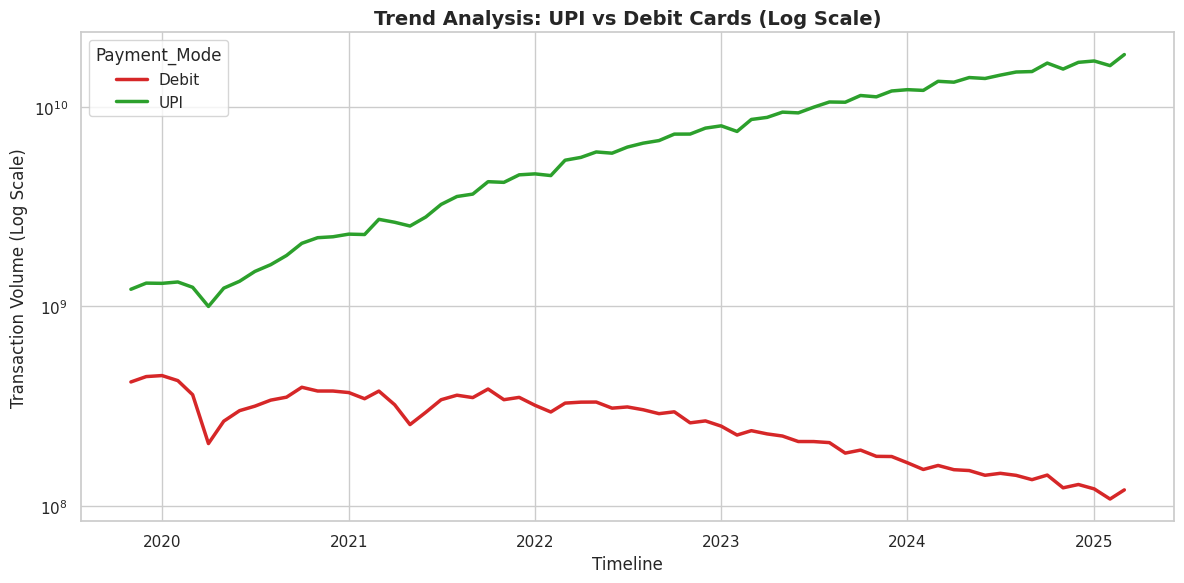

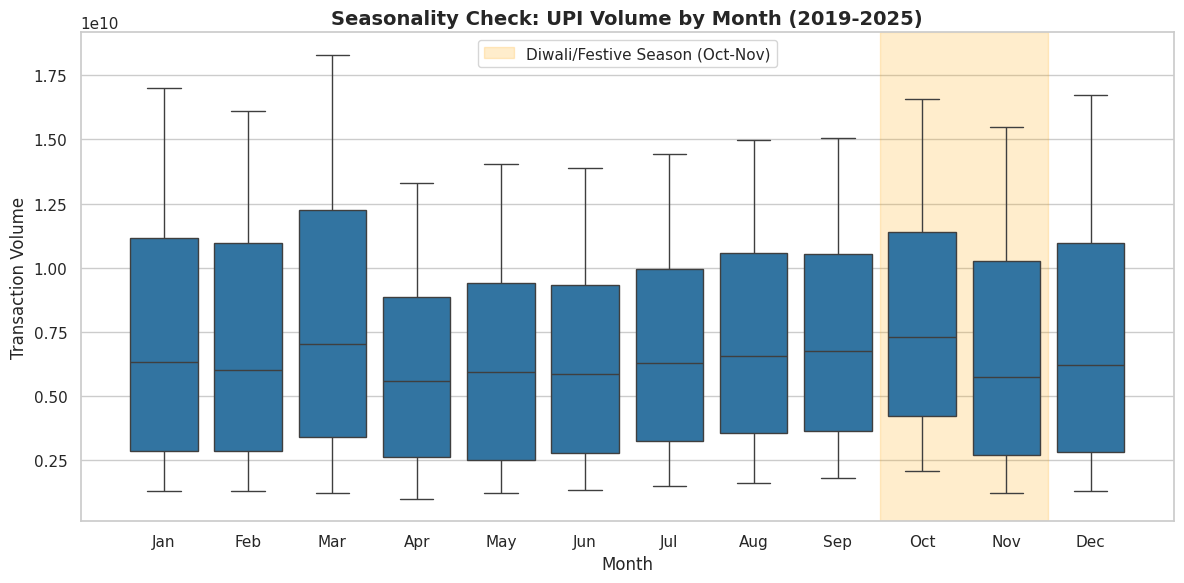

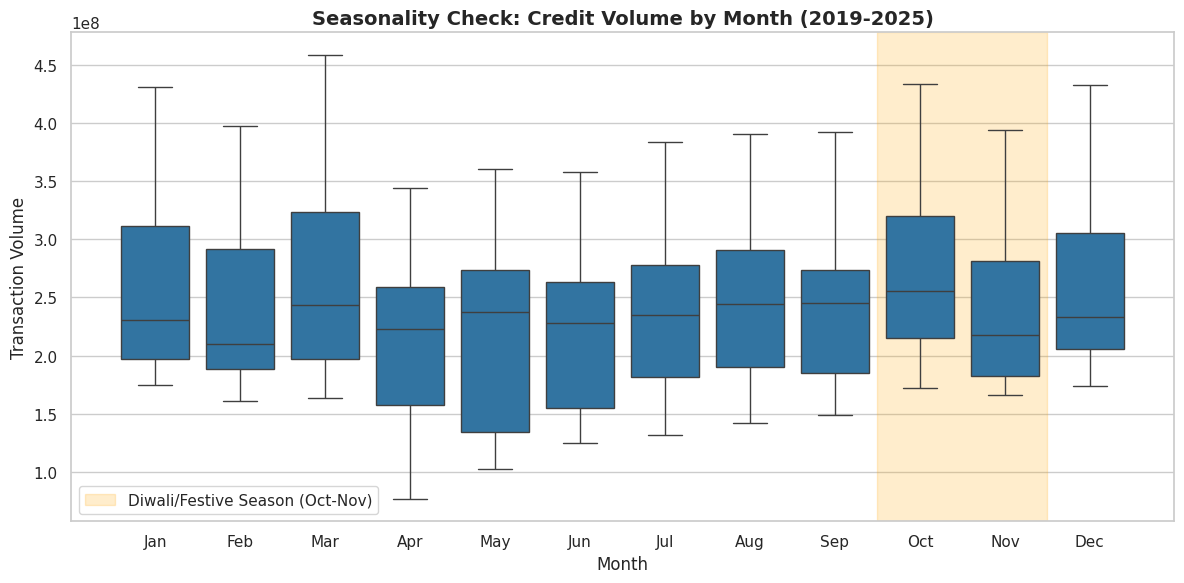

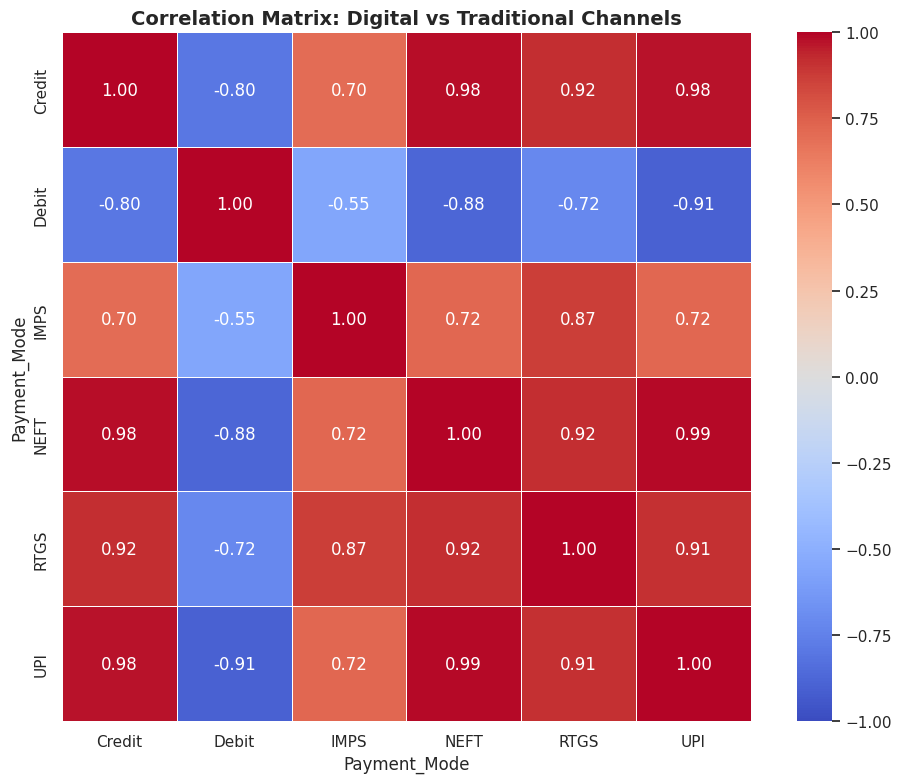

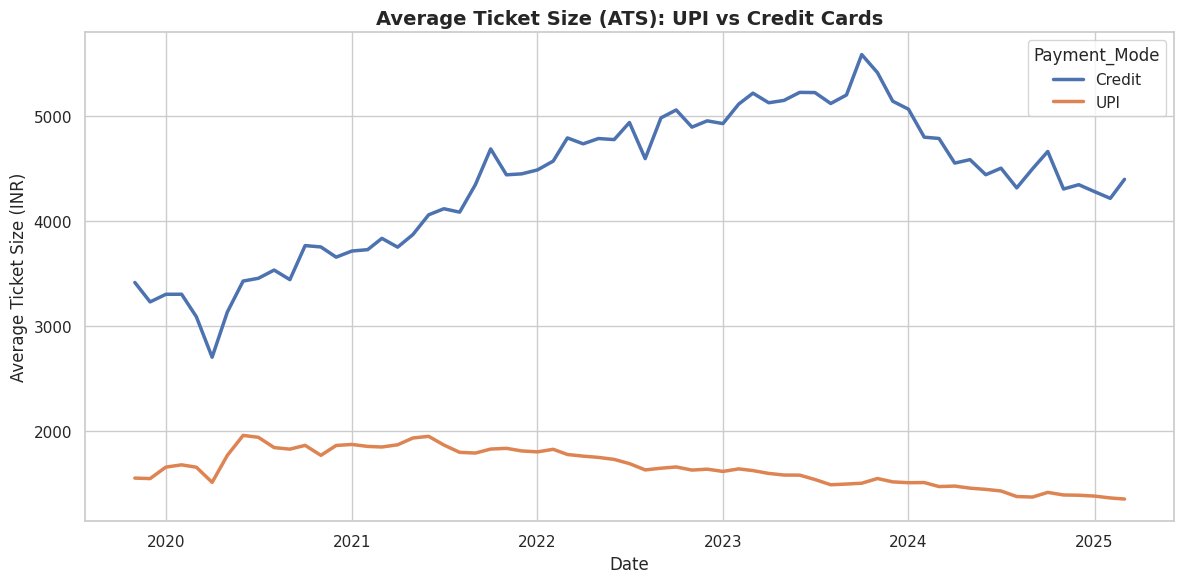

<Figure size 1400x700 with 0 Axes>

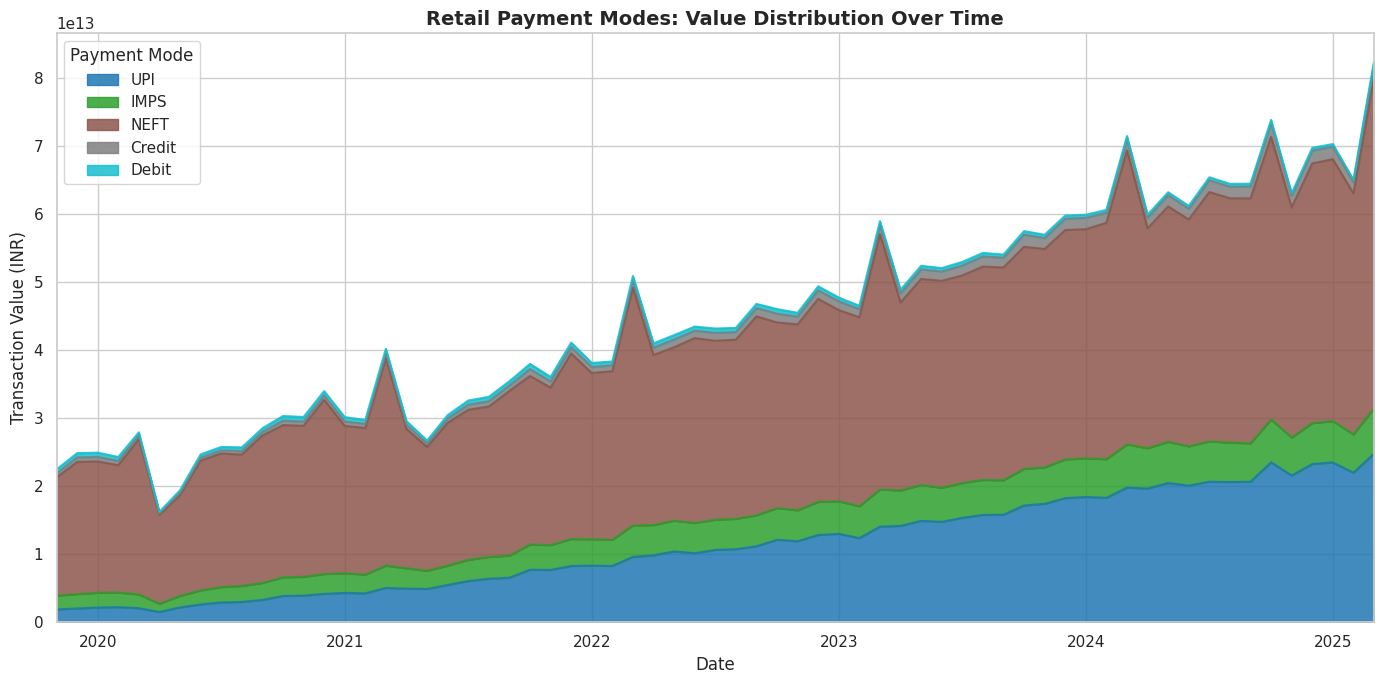

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

def load_and_prep_data(filepath="rbi_payments_clean.csv"):
    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    df['Month_Name'] = df['Date'].dt.strftime('%b')
    df['Year'] = df['Date'].dt.year
    return df

def plot_trend_analysis(df):
    """
    Plots exponential growth of UPI vs stagnation/decline of Debit Cards.
    Log scale applied to handle massive volume disparities.
    """
    plt.figure(figsize=(12, 6))
    target_modes = ["UPI", "Debit"]
    trend_data = df[df["Payment_Mode"].isin(target_modes)]

    ax = sns.lineplot(
        data=trend_data,
        x="Date",
        y="Volume",
        hue="Payment_Mode",
        linewidth=2.5,
        palette={"UPI": "#2ca02c", "Debit": "#d62728"}
    )

    plt.title("Trend Analysis: UPI vs Debit Cards (Log Scale)", fontsize=14, fontweight='bold')
    plt.ylabel("Transaction Volume (Log Scale)")
    plt.xlabel("Timeline")
    plt.yscale("log")

    # Formatting x-axis
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.show()

def plot_seasonality_check(df, target_mode="UPI"):
    """
    Isolates seasonal spikes by analyzing month-over-month volume distributions.
    Highlights Q4 (Oct/Nov) festival spending behavior.
    """
    plt.figure(figsize=(12, 6))
    mode_data = df[df["Payment_Mode"] == target_mode]

    # Sort months chronologically
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    sns.boxplot(
        data=mode_data,
        x="Month_Name",
        y="Volume",
        order=month_order,
        color="#1f77b4"
    )

    plt.title(f"Seasonality Check: {target_mode} Volume by Month (2019-2025)", fontsize=14, fontweight='bold')
    plt.ylabel("Transaction Volume")
    plt.xlabel("Month")

    # Highlight Oct/Nov structurally
    plt.axvspan(8.5, 10.5, color='orange', alpha=0.2, label='Diwali/Festive Season (Oct-Nov)')
    plt.legend()

    plt.show()

def plot_correlation_matrix(df):
    """
    Tests the 'Cash-less Economy' hypothesis.
    Note: Base ETL does not extract ATM data. Using Debit Card usage as a proxy for legacy/cash-adjacent behavior.
    To include ATMs, add ATM columns to `col_map` in ETL Phase 1.
    """
    plt.figure(figsize=(10, 8))

    # Pivot to get modes as columns and Date as index
    pivot_vol = df.pivot(index="Date", columns="Payment_Mode", values="Volume")

    # Calculate Pearson correlation
    corr_matrix = pivot_vol.corr()

    # Generate heatmap
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=.5
    )

    plt.title("Correlation Matrix: Digital vs Traditional Channels", fontsize=14, fontweight='bold')
    plt.show()

# Execution Pipeline
if __name__ == "__main__":
    df_clean = load_and_prep_data()

    # 1. Trend Analysis
    plot_trend_analysis(df_clean)

    # 2. Seasonality Check
    plot_seasonality_check(df_clean, target_mode="UPI")
    plot_seasonality_check(df_clean, target_mode="Credit") # Compare with Credit cards

    # 3. Correlation Matrix
    plot_correlation_matrix(df_clean)

def generate_eda_plots(df: pd.DataFrame):
    """Generates visualizations aligned with project roadmap phases 2 and 3."""
    sns.set_theme(style="whitegrid")


    # 1. Ticket Size Tracker: Premiumization vs Mass Adoption (ATS)
    plt.figure(figsize=(12, 6))
    df_ats = df[df["Payment_Mode"].isin(["UPI", "Credit"])]
    sns.lineplot(data=df_ats, x="Date", y="ATS", hue="Payment_Mode", linewidth=2.5)
    plt.title("Average Ticket Size (ATS): UPI vs Credit Cards", fontsize=14, fontweight='bold')
    plt.ylabel("Average Ticket Size (INR)")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

    # 2. Category War: Payment Mode Market Share by Value over Time
    plt.figure(figsize=(14, 7))
    pivot_value = df.pivot(index="Date", columns="Payment_Mode", values="Value").fillna(0)

    # Exclude RTGS if retail focus is needed (RTGS dwarfs all others in value)
    retail_modes = ["UPI", "IMPS", "NEFT", "Credit", "Debit"]
    pivot_retail = pivot_value[retail_modes]

    pivot_retail.plot.area(figsize=(14, 7), alpha=0.85, colormap="tab10")
    plt.title("Retail Payment Modes: Value Distribution Over Time", fontsize=14, fontweight='bold')
    plt.ylabel("Transaction Value (INR)")
    plt.xlabel("Date")
    plt.legend(title="Payment Mode", loc="upper left")
    plt.tight_layout()
    plt.show()

# Execute plots
generate_eda_plots(df_clean)